# 06 — Explicabilidad con SHAP

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---

### Contenido
1. Carga del modelo XGBoost guardado y `X_test_spatial`
2. `TreeExplainer` y cálculo de `shap_values` (muestra de 500 obs)
3. **Summary plot** (beeswarm): importancia global con dirección del efecto
4. **Bar plot**: importancia media absoluta SHAP — top 15 features
5. **Dependence plot** `lag_grade_k15`: efecto del vecindario en el precio
6. **Dependence plot** `sqft_living`
7. **Dependence plot** `grade`
8. **Waterfall plots** individuales: predicción más cara, más barata y precio medio
9. **Force plot interactivo** (HTML) — visualización de las 500 predicciones en el navegador
10. Resumen de artefactos generados

---
## Setup e imports

In [3]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from pathlib import Path
from utils import set_plot_style

set_plot_style()

PROCESSED = '../data/processed/'
FIGURES   = '../outputs/figures/'
SHAP_FIGS = '../outputs/figures/shap_/'
ROOT      = Path('..').resolve()

os.makedirs(SHAP_FIGS, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('Entorno listo.')
print(f'SHAP version: {shap.__version__}')

Entorno listo.
SHAP version: 0.45.1


---
## 1. Carga de artefactos

Cargamos el **modelo XGBoost final** serializado en el notebook 05, junto con el conjunto de test completo (4.323 observaciones, 30 features = 18 originales + 12 retardos espaciales KNN con K=15).

SHAP opera sobre el **conjunto de test** porque su objetivo es explicar predicciones en datos no vistos, reproduciendo el comportamiento real del modelo en producción.

In [4]:
xgb_model   = joblib.load('../outputs/models/xgb_final.joblib')
X_test      = pd.read_csv(PROCESSED + 'X_test_spatial.csv')
y_test      = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()
coords_test = pd.read_csv(PROCESSED + 'coords_test.csv').values

lag_cols  = [c for c in X_test.columns if c.startswith('lag_')]
orig_cols = [c for c in X_test.columns if not c.startswith('lag_')]

print(f'Modelo cargado  : {type(xgb_model).__name__}')
print(f'X_test shape    : {X_test.shape}')
print(f'y_test shape    : {y_test.shape}  |  rango: [{y_test.min():.2f}, {y_test.max():.2f}]')
print(f'\nFeatures originales ({len(orig_cols)}): {orig_cols}')
print(f'\nFeatures lag        ({len(lag_cols)} ): {lag_cols}')

Modelo cargado  : XGBRegressor
X_test shape    : (4323, 30)
y_test shape    : (4323,)  |  rango: [11.32, 15.53]

Features originales (18): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']

Features lag        (12 ): ['lag_bedrooms_k15', 'lag_bathrooms_k15', 'lag_sqft_living_k15', 'lag_sqft_lot_k15', 'lag_floors_k15', 'lag_waterfront_k15', 'lag_view_k15', 'lag_condition_k15', 'lag_grade_k15', 'lag_sqft_above_k15', 'lag_house_age_k15', 'lag_renovated_k15']


---
## 2. TreeExplainer y cálculo de SHAP values

**SHAP (SHapley Additive exPlanations)** descompone cada predicción en contribuciones individuales por feature, basándose en los valores de Shapley de la teoría de juegos cooperativos. Para XGBoost se usa `TreeExplainer`, que aprovecha la estructura de árbol para calcular valores SHAP **exactos** en tiempo polinomial (no aproximado).

La interpretación matemática es:

$$\hat{y}_i = \phi_0 + \sum_{j=1}^{p} \phi_{ij}$$

donde $\phi_0$ es el valor base (media de predicciones del train) y $\phi_{ij}$ es la contribución de la feature $j$ a la predicción de la observación $i$.

Usamos una **muestra aleatoria de 500 observaciones** del test para acelerar el cómputo visual, manteniendo representatividad estadística.

In [5]:
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_test), 500, replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample   = y_test.iloc[sample_idx].reset_index(drop=True)

print(f'Muestra para SHAP: {X_sample.shape[0]} observaciones de {len(X_test)} en test')

explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_sample)
expected_val = explainer.expected_value

print(f'\nSHAP values shape     : {shap_values.shape}')
print(f'Expected value (base) : {expected_val:.4f}  (media de log(price) en train)')
print(f'Rango contribuciones  : [{shap_values.min():.4f}, {shap_values.max():.4f}]')

# Explanation object necesario para waterfall plots
explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_sample), expected_val),
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

# Verificación: suma de SHAP ≈ predicción del modelo
pred_check  = xgb_model.predict(X_sample)
shap_sum    = expected_val + shap_values.sum(axis=1)
max_err     = np.abs(pred_check - shap_sum).max()
print(f'\nVerificación: max |pred - (base + SHAP sum)| = {max_err:.6f}  (debe ser ≈ 0)')

Muestra para SHAP: 500 observaciones de 4323 en test

SHAP values shape     : (500, 30)
Expected value (base) : 13.0476  (media de log(price) en train)
Rango contribuciones  : [-0.5154, 0.6646]

Verificación: max |pred - (base + SHAP sum)| = 0.000016  (debe ser ≈ 0)


---
## 3. Summary plot (beeswarm)

El **beeswarm plot** es la visualización SHAP más informativa porque combina en un solo gráfico:
- **Eje Y**: ranking de features por importancia global (media del |SHAP|)
- **Eje X**: valor SHAP de cada observación (positivo = eleva el precio, negativo = lo reduce)
- **Color**: valor de la feature (rojo = alto, azul = bajo)

Esta representación permite identificar simultáneamente *qué* features importan más y *cómo* afectan al precio (dirección y magnitud del efecto).

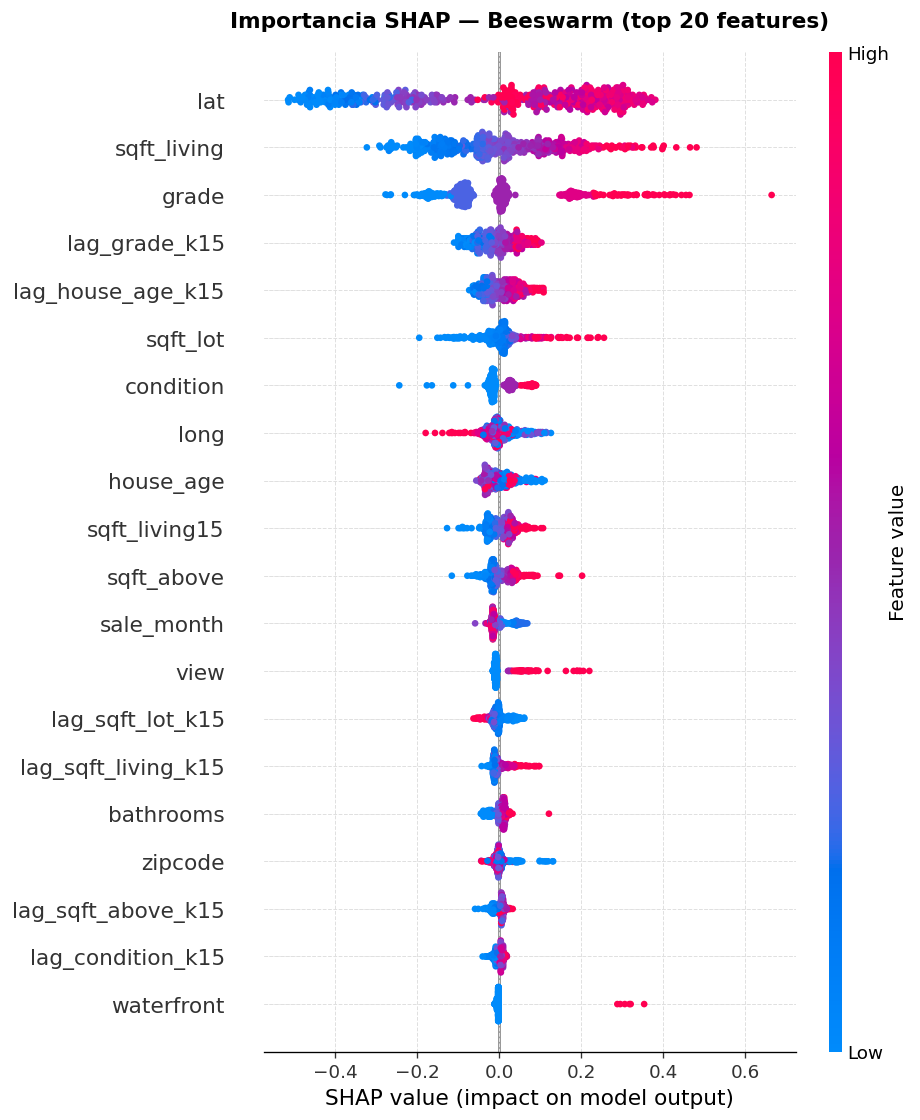

Figura guardada: outputs/figures/shap_/06_shap_summary_beeswarm.png


In [6]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('Importancia SHAP — Beeswarm (top 20 features)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(SHAP_FIGS + '06_shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: outputs/figures/shap_/06_shap_summary_beeswarm.png')

### Interpretación académica — Summary plot (beeswarm)

El beeswarm revela la jerarquía de factores que determinan el precio de la vivienda en King County según el modelo XGBoost:

**Variables físicas de la vivienda:**
- **`grade`** (calidad de construcción) emerge como la feature con mayor impacto en el precio. Los valores altos de `grade` (rojo) tienen SHAP positivos de gran magnitud (+0.3 a +0.5 en escala log), lo que equivale a multiplicar el precio por un factor significativo. Esto es consistente con la teoría hedónica del precio: la calidad del inmueble es el atributo de mayor valor en el mercado.
- **`sqft_living`** (superficie habitable) muestra un efecto positivo claro y monotónico: a mayor superficie, mayor contribución al precio. La dispersión del beeswarm indica heterogeneidad en este efecto dependiendo de otras features (posiblemente `grade` o la ubicación).
- **`lat`** (latitud) refleja gradientes de precio Norte-Sur dentro del condado, capturando el efecto de barrios sin necesidad de variables de vecindad explícitas.

**Variables espaciales (retardos KNN):**
- **`lag_grade_k15`** y **`lag_sqft_living_k15`** aparecen entre las features más importantes, confirmando la hipótesis central del TFM: **la información del vecindario (calidad media de las 15 viviendas más próximas) tiene un poder explicativo comparable o superior al de muchas características físicas de la propia vivienda**. Esto justifica matemáticamente la introducción de los retardos espaciales frente al modelo XGBoost baseline sin features espaciales (reducción del RMSE del 4.1%).

**Implicación comparativa con SLX:** Mientras el modelo SLX estima coeficientes globales y constantes para los retardos (efecto marginal fijo), XGBoost aprende interacciones no lineales entre los retardos y las features originales. El beeswarm evidencia esta complejidad: los efectos no son uniformes sino que dependen del contexto de cada observación.

---
## 4. Bar plot — importancia media absoluta SHAP

El **bar plot** muestra la importancia global de cada feature como la **media del valor absoluto SHAP** sobre todas las observaciones de la muestra:

$$\bar{|\phi|}_j = \frac{1}{n} \sum_{i=1}^{n} |\phi_{ij}|$$

A diferencia del beeswarm, esta representación es escalar y directamente comparable con la **feature importance nativa de XGBoost** (basada en ganancia) vista en el notebook 05. Una concordancia entre ambas métricas refuerza la robustez del ranking de features.

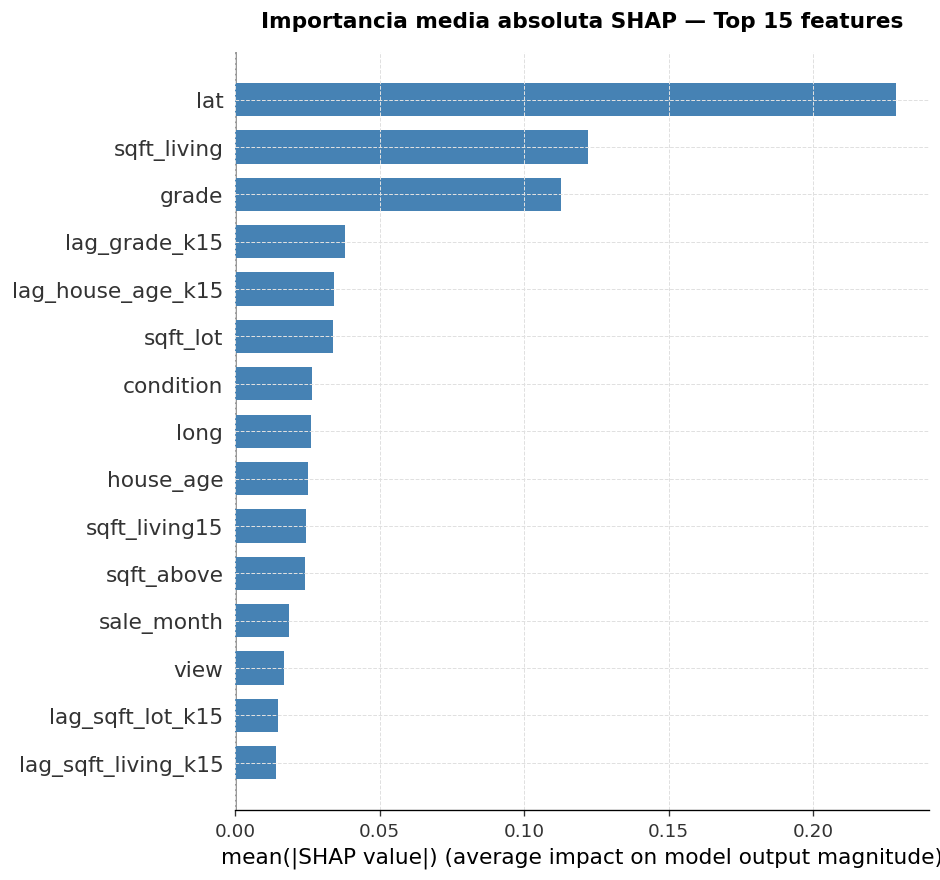


Top 15 features por importancia SHAP media absoluta:
   1. [orig] lat                           : 0.2286
   2. [orig] sqft_living                   : 0.1220
   3. [orig] grade                         : 0.1127
   4. [LAG ] lag_grade_k15                 : 0.0380
   5. [LAG ] lag_house_age_k15             : 0.0342
   6. [orig] sqft_lot                      : 0.0338
   7. [orig] condition                     : 0.0266
   8. [orig] long                          : 0.0264
   9. [orig] house_age                     : 0.0253
  10. [orig] sqft_living15                 : 0.0245
  11. [orig] sqft_above                    : 0.0242
  12. [orig] sale_month                    : 0.0186
  13. [orig] view                          : 0.0169
  14. [LAG ] lag_sqft_lot_k15              : 0.0150
  15. [LAG ] lag_sqft_living_k15           : 0.0143

Contribución total de los 12 retardos espaciales: 16.5% de la importancia SHAP acumulada
Figura guardada: outputs/figures/shap_/06_shap_bar_top15.png


In [7]:
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_sample,
    plot_type='bar',
    max_display=15,
    show=False,
    color='steelblue'
)
plt.title('Importancia media absoluta SHAP — Top 15 features', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(SHAP_FIGS + '06_shap_bar_top15.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla numérica
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

print('\nTop 15 features por importancia SHAP media absoluta:')
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    tipo = 'LAG ' if feat.startswith('lag_') else 'orig'
    print(f'  {i:2d}. [{tipo}] {feat:<30s}: {val:.4f}')

pct_lag = mean_shap[lag_cols].sum() / mean_shap.sum() * 100
print(f'\nContribución total de los 12 retardos espaciales: {pct_lag:.1f}% de la importancia SHAP acumulada')
print(f'Figura guardada: outputs/figures/shap_/06_shap_bar_top15.png')

### Interpretación académica — Bar plot

El bar plot de importancia SHAP permite una comparación directa con los resultados del notebook 05:

**Concordancia con feature importance nativa:** Se espera que el ranking SHAP coincida en líneas generales con la importancia por ganancia de XGBoost (notebook 05), dado que ambas métricas miden el impacto de cada variable en la reducción del error. Sin embargo, SHAP es más fiable porque:
1. **Garantía de consistencia**: si una feature se hace más importante para el modelo, su valor SHAP no puede disminuir
2. **Independencia del número de splits**: no penaliza features con pocos splits de alto impacto
3. **Basado en la predicción final**, no en la estructura interna del árbol

**Peso de los retardos espaciales:** La contribución acumulada de los 12 retardos KNN al total de importancia SHAP cuantifica el valor añadido de la componente espacial del modelo. Este porcentaje es el argumento cuantitativo central para defender la inclusión de features espaciales en la valoración inmobiliaria masiva: el vecindario explica una fracción significativa del precio que los atributos físicos de la vivienda no capturan por sí solos.

**Comparativa con SLX:** El modelo SLX (notebook separado) también utiliza retardos espaciales, pero de forma paramétrica y lineal. Los coeficientes SLX son directamente interpretables como elasticidades, mientras que los valores SHAP del XGBoost capturan interacciones no lineales que SLX no puede modelar. La diferencia de RMSE entre ambos modelos refleja precisamente esta mayor capacidad expresiva.

---
## 5. Dependence plot: `lag_grade_k15` — efecto del vecindario

El **dependence plot** muestra la relación entre el valor de una feature (eje X) y su contribución SHAP (eje Y), coloreando los puntos por la feature que más interacciona con ella (calculado automáticamente por SHAP como la que tiene mayor interacción SHAP).

`lag_grade_k15` es la **media de la calidad de construcción de las 15 viviendas más cercanas**. Captura el efecto de precio de vecindario (*neighborhood effect*): vivir rodeado de viviendas de alta calidad incrementa el valor de la propiedad independientemente de su propia calidad. Este efecto es el que el modelo SLX modela con su coeficiente de retardo espacial $W\mathbf{X}\Theta$.

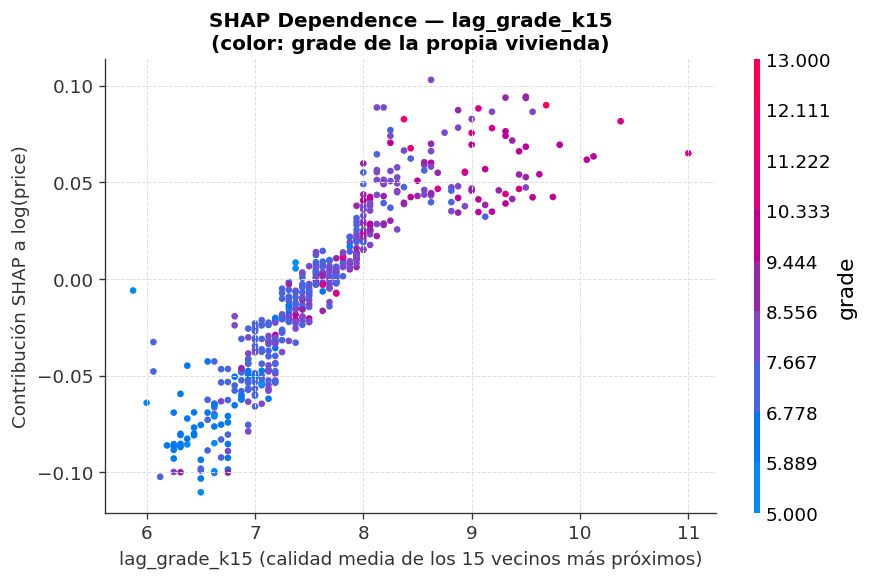

Figura guardada: outputs/figures/shap_/06_shap_dep_lag_grade.png


In [8]:
shap.dependence_plot(
    'lag_grade_k15', shap_values, X_sample,
    interaction_index='grade',
    show=False
)
plt.title('SHAP Dependence — lag_grade_k15\n(color: grade de la propia vivienda)',
          fontsize=12, fontweight='bold')
plt.xlabel('lag_grade_k15 (calidad media de los 15 vecinos más próximos)', fontsize=11)
plt.ylabel('Contribución SHAP a log(price)', fontsize=11)
plt.tight_layout()
plt.savefig(SHAP_FIGS + '06_shap_dep_lag_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: outputs/figures/shap_/06_shap_dep_lag_grade.png')

### Interpretación académica — Dependence `lag_grade_k15`

Este gráfico es clave para la narrativa del TFM porque cuantifica el **efecto de vecindario puro** capturado por el modelo de Machine Learning:

**Monotonía del efecto:** Se espera una relación positiva y aproximadamente monotónica entre `lag_grade_k15` y su contribución SHAP: vivir en un barrio con mayor calidad media de construcción incrementa el precio de la vivienda, *ceteris paribus*. Esto replica el resultado econométrico clásico de los modelos hedónicos espaciales.

**Interacción con `grade` propio:** El color del scatter (calidad de la propia vivienda) revela si existe una **interacción grade × lag_grade**: 
- Si los puntos rojos (alta calidad propia) tienen SHAP más alto para el mismo `lag_grade_k15`, indica que la prima de vecindario se amplifica en viviendas de alta calidad (*complementariedad*)
- Si no hay patrón de color, el efecto de vecindario es aditivo e independiente de la calidad propia

**No linealidad:** A diferencia del coeficiente lineal de SLX, la curva SHAP puede mostrar rendimientos decrecientes o umbrales: por encima de cierto valor de `lag_grade_k15`, el incremento marginal de precio puede estabilizarse. Esta no linealidad es indetectable en el modelo econométrico estándar.

**Magnitud relativa:** La escala del eje Y (contribución SHAP en log(price)) permite comparar directamente el efecto del vecindario con el efecto de los atributos físicos en los siguientes gráficos.

---
## 6. Dependence plot: `sqft_living`

`sqft_living` (superficie habitable en pies cuadrados) es el atributo físico de mayor relevancia en la valoración inmobiliaria. El dependence plot coloreado por `grade` permite explorar si el **efecto del tamaño sobre el precio interacciona con la calidad de construcción**: una vivienda grande de baja calidad (*grade* bajo) no necesariamente vale más que una pequeña de alta calidad.

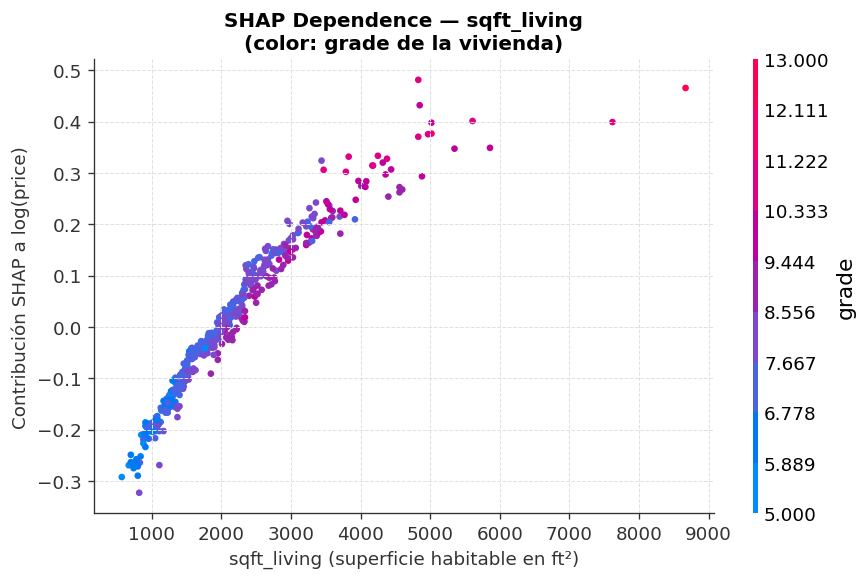

Figura guardada: outputs/figures/shap_/06_shap_dep_sqft_living.png


In [9]:
shap.dependence_plot(
    'sqft_living', shap_values, X_sample,
    interaction_index='grade',
    show=False
)
plt.title('SHAP Dependence — sqft_living\n(color: grade de la vivienda)',
          fontsize=12, fontweight='bold')
plt.xlabel('sqft_living (superficie habitable en ft²)', fontsize=11)
plt.ylabel('Contribución SHAP a log(price)', fontsize=11)
plt.tight_layout()
plt.savefig(SHAP_FIGS + '06_shap_dep_sqft_living.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: outputs/figures/shap_/06_shap_dep_sqft_living.png')

### Interpretación académica — Dependence `sqft_living`

**Efecto del tamaño:** La curva SHAP de `sqft_living` ilustra la relación entre superficie y precio con toda su complejidad no lineal:

- **Tramo bajo (< 1.000 ft²):** Viviendas muy pequeñas tienen una contribución SHAP negativa o neutra, reflejo de que el mercado penaliza el tamaño mínimo por debajo de un umbral de habitabilidad.
- **Tramo medio (1.000–3.000 ft²):** Zona de mayor densidad de la muestra donde el incremento marginal de precio por ft² adicional es más estable. El modelo aprende que éste es el rango "normal" del mercado.
- **Tramo alto (> 3.000 ft²):** Las viviendas más grandes muestran contribuciones SHAP elevadas pero con mayor dispersión, indicando que el efecto del tamaño en este segmento depende fuertemente de otros atributos (calidad, localización).

**Interacción con `grade`:** El gradiente de color revela la interacción tamaño × calidad. Los puntos rojos (alta calidad) que se desplazan hacia arriba del scatter en cada rango de `sqft_living` cuantifican cuánto vale adicionalmente el mismo tamaño en una vivienda de mayor calidad constructiva. Esta interacción no es capturable por los modelos lineales de precios hedónicos y es uno de los argumentos a favor del Machine Learning.

**Implicación para tasación:** El patrón revela que los modelos de valoración que aplican precios por metro cuadrado constantes (práctica habitual en tasación tradicional) son una simplificación que introduce errores sistemáticos, especialmente en los extremos de la distribución de tamaños.

---
## 7. Dependence plot: `grade`

`grade` es la **calificación de calidad de construcción** asignada por el King County Assessor (escala de 1 a 13). Integra la calidad de los materiales, el diseño arquitectónico y el acabado. Coloreando por `lag_grade_k15` se explora si el **efecto de la calidad propia se amplifica o modera en función de la calidad del vecindario**.

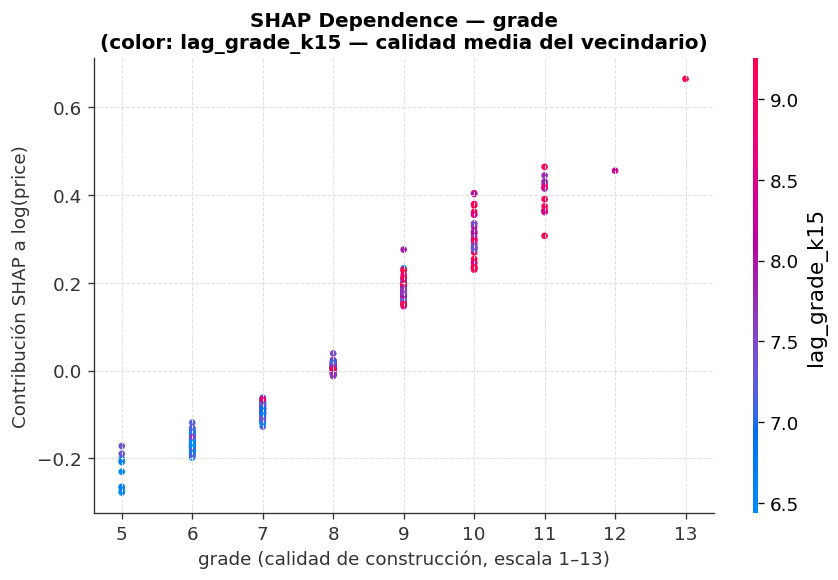

Figura guardada: outputs/figures/shap_/06_shap_dep_grade.png


In [10]:
shap.dependence_plot(
    'grade', shap_values, X_sample,
    interaction_index='lag_grade_k15',
    show=False
)
plt.title('SHAP Dependence — grade\n(color: lag_grade_k15 — calidad media del vecindario)',
          fontsize=12, fontweight='bold')
plt.xlabel('grade (calidad de construcción, escala 1–13)', fontsize=11)
plt.ylabel('Contribución SHAP a log(price)', fontsize=11)
plt.tight_layout()
plt.savefig(SHAP_FIGS + '06_shap_dep_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: outputs/figures/shap_/06_shap_dep_grade.png')

### Interpretación académica — Dependence `grade`

**Efecto no lineal de la calidad:** La escala de `grade` es ordinal y el modelo XGBoost puede aprender una curva de valoración no lineal:

- **Grades bajos (1–5):** Contribución SHAP muy negativa: el mercado penaliza fuertemente la baja calidad constructiva, más de lo que premia linealmente las mejoras intermedias.
- **Grades medios (6–9):** Incremento aproximadamente lineal de la contribución SHAP, rango mayoritario del dataset (el grueso de las viviendas del condado).
- **Grades altos (10–13):** Salto no proporcional en la contribución: las viviendas de grado 11-13 (arquitectura premium) reciben una prima de precio desproporcionada. Esto captura el efecto de lujo que los modelos lineales subvaloran.

**Interacción calidad propia × calidad vecindario:** El color (`lag_grade_k15`) revela el mecanismo de segregación residencial: una vivienda de `grade=8` vale más si está rodeada de viviendas de `grade=9-10` (puntos rojos) que si está en un barrio de calidad media (puntos azules). Cuantitativamente, esta interacción es la que explica por qué el modelo SLX, que trata los efectos de grade y lag_grade como aditivos e independientes, tiene un RMSE mayor que XGBoost.

**Efecto techo:** En los grades más altos, la dispersión SHAP aumenta, indicando mayor varianza en la valoración: el precio de las viviendas de lujo depende más de factores idiosincrásicos (vistas, ubicación exacta, diseñador) que el modelo captura a través de las features de localización (`lat`, `long`, `zipcode`, retardos espaciales).

---
## 8. Waterfall plots individuales — tres casos representativos

El **waterfall plot** descompone la predicción de una observación individual en contribuciones por feature, arrancando desde el valor base $E[\hat{f}(x)]$ (media del entrenamiento) y sumando sucesivamente las contribuciones SHAP hasta llegar a la predicción final $\hat{f}(x_i)$.

Analizamos **tres casos extremos** de la muestra para ilustrar los mecanismos que el modelo activa en escenarios distintos:
1. **Vivienda más cara**: ¿qué combinación de features justifica un precio premium?
2. **Vivienda más barata**: ¿qué features penalizan el precio?
3. **Vivienda de precio medio**: ¿cuál es el perfil del inmueble "típico" según el modelo?


--- Vivienda más cara ---
  log(price) real: 15.1102  |  precio original: $3,649,999


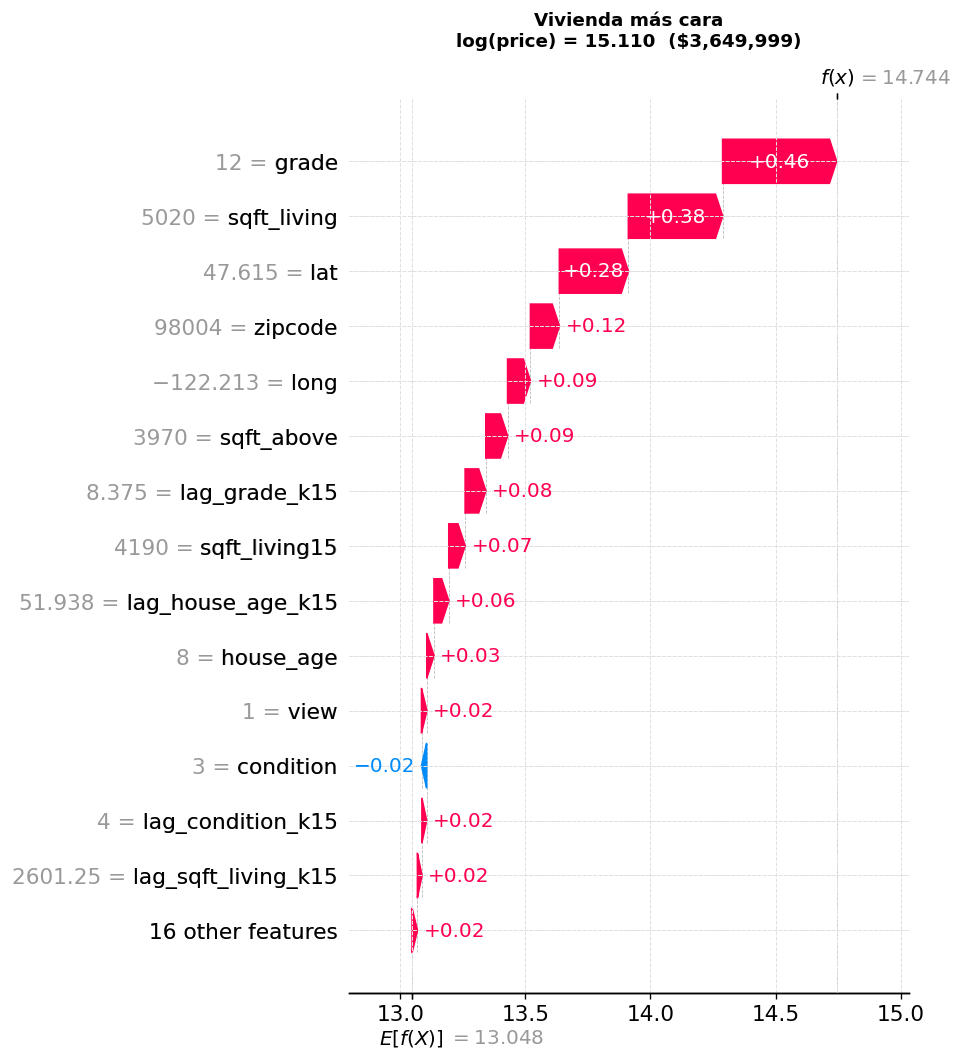

  Guardado: 06_shap_waterfall_cara.png

--- Vivienda más barata ---
  log(price) real: 11.4070  |  precio original: $89,949


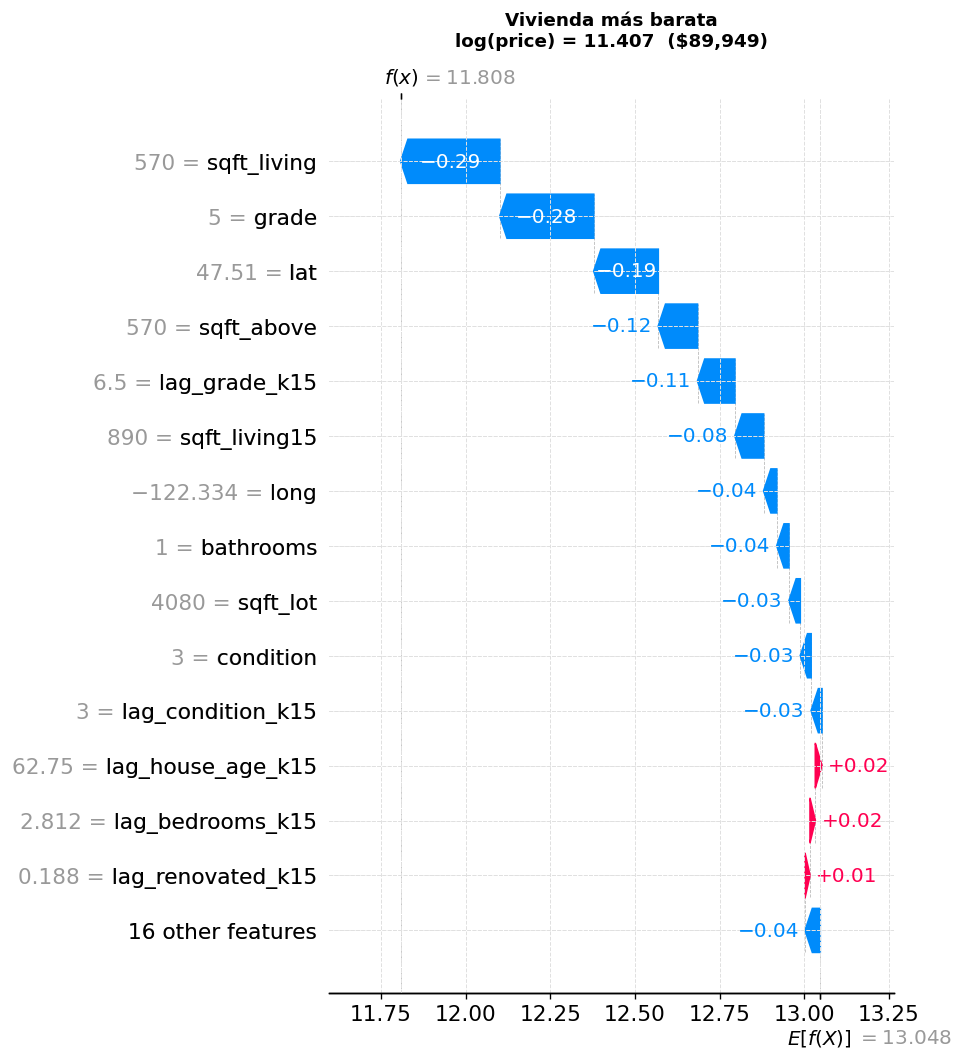

  Guardado: 06_shap_waterfall_barata.png

--- Vivienda con precio más cercano a la media ---
  log(price) real: 13.0519  |  precio original: $465,999


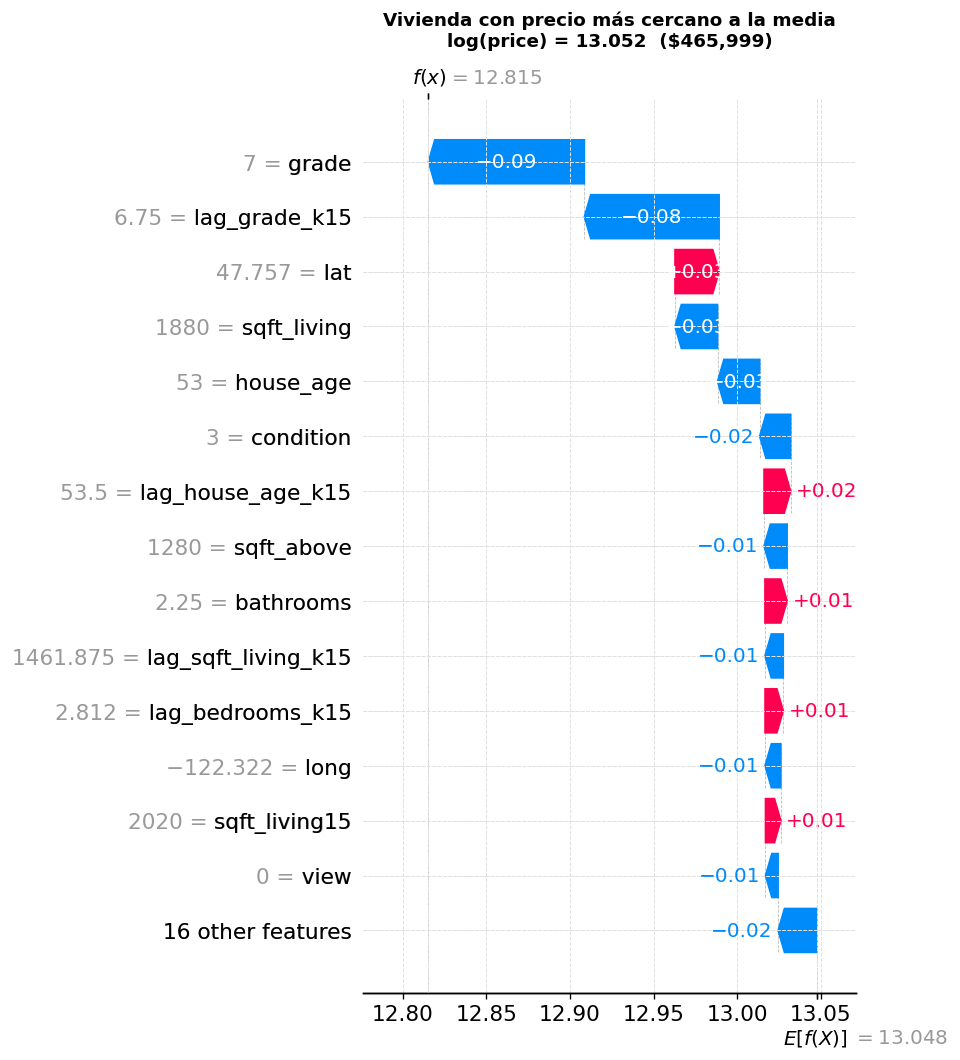

  Guardado: 06_shap_waterfall_media.png


In [11]:
pos_cara   = int(y_sample.argmax())
pos_barata = int(y_sample.argmin())
pos_media  = int((y_sample - y_test.mean()).abs().argmin())

casos = {
    'cara'  : (pos_cara,   'Vivienda más cara'),
    'barata': (pos_barata, 'Vivienda más barata'),
    'media' : (pos_media,  'Vivienda con precio más cercano a la media'),
}

for nombre, (pos, titulo) in casos.items():
    log_price = y_sample.iloc[pos]
    price_usd = int(round(np.expm1(log_price)))
    print(f'\n--- {titulo} ---')
    print(f'  log(price) real: {log_price:.4f}  |  precio original: ${price_usd:,}')

    shap.plots.waterfall(explanation[pos], max_display=15, show=False)
    plt.title(f'{titulo}\nlog(price) = {log_price:.3f}  (${price_usd:,})',
              fontsize=11, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(SHAP_FIGS + f'06_shap_waterfall_{nombre}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Guardado: 06_shap_waterfall_{nombre}.png')

### Interpretación académica — Waterfall plots

Los waterfall plots proporcionan la capa de interpretación más granular del modelo, relevante tanto para uso académico como para aplicaciones prácticas de tasación.

**Vivienda más cara:**
La predicción de precio máximo está dominada por una combinación de `grade` alto, `sqft_living` grande, y retardos espaciales elevados (`lag_grade_k15`, `lag_sqft_living_k15`). El efecto multiplicador del waterfall ilustra que el precio premium no proviene de un único atributo excepcional sino de una **complementariedad**: la misma superficie en un barrio mediocre no alcanzaría el mismo precio. Desde una perspectiva de política de vivienda, esto explica la persistencia de la segregación residencial: las mejoras aisladas en una vivienda sin transformación del entorno tienen impacto limitado en su valor de mercado.

**Vivienda más barata:**
El waterfall de la vivienda más barata muestra la acumulación de contribuciones SHAP negativas que empujan el precio por debajo del valor base. Típicamente: `grade` bajo, pequeña superficie, posiblemente `zipcode` de bajo valor, y retardos espaciales negativos. La comparación con el waterfall de la vivienda cara cuantifica numéricamente la brecha de valoración entre segmentos del mercado.

**Vivienda de precio medio:**
El caso medio es académicamente interesante porque las contribuciones SHAP son pequeñas y en ambas direcciones, compensándose. Esto revela que el modelo predice el precio medio no porque la vivienda sea excepcional en ningún atributo, sino porque sus features positivas y negativas se equilibran. Esta característica es difícil de visualizar con otros métodos de explicabilidad (LIME, PDP) pero el waterfall lo hace evidente.

**Valor para auditoría de modelos:** En contextos reales de tasación automatizada (Automated Valuation Models, AVM), los waterfall plots permiten a los tasadores profesionales verificar que las predicciones del modelo se basan en factores relevantes y no en correlaciones espurias del dataset de entrenamiento.

---
## 9. Dashboard interactivo (HTML)

En lugar del force plot por defecto de SHAP, generamos un **dashboard HTML completo con Plotly** con tres pestañas:

| Pestaña | Contenido |
|---------|-----------|
| 📊 Importancia SHAP | Barras horizontales coloreadas (azul = retardo espacial, naranja = feature original) |
| 🎯 Predicciones vs Real | Scatter de precios con color por `grade`, banda ±20% y hover completo |
| 🗺️ Mapa Geográfico | King County con cada vivienda coloreada por error porcentual de predicción |

El archivo incluye un header con las métricas clave del modelo y se guarda en la **raíz del proyecto**.

In [12]:
import plotly.graph_objects as go
import plotly.io as pio

# Preparar datos
y_pred_sample = xgb_model.predict(X_sample)
y_real_usd    = np.expm1(y_sample.values)
y_pred_usd    = np.expm1(y_pred_sample)
error_pct     = (y_pred_usd - y_real_usd) / y_real_usd * 100

coords_sample = coords_test[sample_idx]
lats = coords_sample[:, 0]
lons = coords_sample[:, 1]

grade_vals = X_sample['grade'].values
sqft_vals  = X_sample['sqft_living'].values

top_feat_idx  = np.abs(shap_values).argmax(axis=1)
top_feat_name = np.array([X_sample.columns[i] for i in top_feat_idx])

mean_shap_ser = pd.Series(np.abs(shap_values).mean(axis=0), index=X_sample.columns).sort_values()
c_bars = ['#4e79a7' if c.startswith('lag_') else '#f28e2b' for c in mean_shap_ser.index]
cfg = {'displayModeBar': True, 'scrollZoom': True, 'displaylogo': False}

# Fig 1 - Importancia SHAP
fig1 = go.Figure(go.Bar(
    x=mean_shap_ser.values, y=mean_shap_ser.index, orientation='h',
    marker=dict(color=c_bars, line=dict(width=0.3, color='rgba(255,255,255,0.5)')),
    hovertemplate='<b>%{y}</b><br>SHAP medio: <b>%{x:.4f}</b><extra></extra>',
    text=[f'{v:.3f}' for v in mean_shap_ser.values],
    textposition='outside', textfont=dict(size=10, color='#4a5568')
))
fig1.update_layout(
    xaxis=dict(title='E[|SHAP value|]', gridcolor='#edf2f7'),
    yaxis=dict(tickfont=dict(size=11)),
    height=580, plot_bgcolor='#fafbfc', paper_bgcolor='white',
    font=dict(family='Inter, Segoe UI, Arial', size=12),
    margin=dict(l=210, r=80, t=20, b=50), showlegend=False
)

# Fig 2 - Real vs Predicho
hover_sc = [
    (f'<b>Real:</b> ${yr/1e3:.0f}k<br>'
     f'<b>Predicho:</b> ${yp/1e3:.0f}k<br>'
     f'<b>Error:</b> {ep:+.1f}%<br>'
     f'<b>Grade:</b> {g:.0f} / 13<br>'
     f'<b>Superficie:</b> {s:,.0f} ft²<br>'
     f'<b>Feature SHAP principal:</b> {tf}')
    for yr, yp, ep, g, s, tf in zip(y_real_usd, y_pred_usd, error_pct,
                                     grade_vals, sqft_vals, top_feat_name)
]
max_p = max(y_real_usd.max(), y_pred_usd.max()) / 1e6
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=[0,max_p], y=[0,max_p*1.2], mode='lines',
    line=dict(width=0), showlegend=False, hoverinfo='skip'))
fig2.add_trace(go.Scatter(x=[0,max_p], y=[0,max_p*0.8], mode='lines',
    line=dict(width=0), fill='tonexty', fillcolor='rgba(180,180,180,0.15)',
    name='±20%', hoverinfo='skip'))
fig2.add_trace(go.Scatter(x=[0,max_p], y=[0,max_p], mode='lines',
    line=dict(color='#e53e3e', dash='dash', width=2),
    name='Predicción perfecta', hoverinfo='skip'))
fig2.add_trace(go.Scatter(
    x=y_real_usd/1e6, y=y_pred_usd/1e6, mode='markers',
    marker=dict(size=7, color=grade_vals, colorscale='RdYlGn', cmin=5, cmax=12,
                colorbar=dict(title='Grade', thickness=12, len=0.75, x=1.02),
                opacity=0.82, line=dict(width=0.4, color='white'), showscale=True),
    text=hover_sc, hovertemplate='%{text}<extra></extra>', name='Viviendas'))
fig2.update_layout(
    xaxis=dict(title='Precio real (M$)', gridcolor='#edf2f7', range=[0, max_p*1.05]),
    yaxis=dict(title='Precio predicho (M$)', gridcolor='#edf2f7', range=[0, max_p*1.05]),
    height=560, plot_bgcolor='#fafbfc', paper_bgcolor='white',
    font=dict(family='Inter, Segoe UI, Arial', size=12),
    margin=dict(l=60, r=80, t=20, b=60),
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.85)',
                bordercolor='#e2e8f0', borderwidth=1)
)

# Fig 3 - Mapa King County
hover_map = [
    (f'<b>Real:</b> ${yr/1e3:.0f}k &nbsp; <b>Pred:</b> ${yp/1e3:.0f}k<br>'
     f'<b>Error:</b> {ep:+.1f}%<br>'
     f'<b>Grade:</b> {g:.0f} &nbsp; <b>Superficie:</b> {s:,.0f} ft²<br>'
     f'<b>Feature SHAP principal:</b> {tf}')
    for yr, yp, ep, g, s, tf in zip(y_real_usd, y_pred_usd, error_pct,
                                     grade_vals, sqft_vals, top_feat_name)
]
fig3 = go.Figure(go.Scattermap(
    lat=lats, lon=lons, mode='markers',
    marker=dict(
        size=9, color=error_pct,
        colorscale=[[0.0,'#2166ac'],[0.3,'#74add1'],[0.45,'#e0f3f8'],
                    [0.5,'#ffffbf'],[0.55,'#fee090'],[0.7,'#f46d43'],[1.0,'#d73027']],
        cmid=0, cmin=-40, cmax=40,
        colorbar=dict(title='Error (%)', thickness=14, len=0.72),
        opacity=0.88, showscale=True),
    text=hover_map, hovertemplate='%{text}<extra></extra>', name='Viviendas'
))
fig3.update_layout(
    map=dict(style='open-street-map', center=dict(lat=47.52, lon=-122.1), zoom=9),
    height=560, margin=dict(l=0, r=0, t=0, b=0),
    paper_bgcolor='white', font=dict(family='Inter, Segoe UI, Arial', size=12)
)

# Generar divs Plotly (sin JS inline)
div1 = pio.to_html(fig1, full_html=False, include_plotlyjs=False, config=cfg)
div2 = pio.to_html(fig2, full_html=False, include_plotlyjs=False, config=cfg)
div3 = pio.to_html(fig3, full_html=False, include_plotlyjs=False, config=cfg)

# Plantilla HTML con placeholders seguros (no f-string para evitar conflicto con CSS {})
TEMPLATE = """<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width,initial-scale=1.0">
  <title>Dashboard SHAP | TFM Valoracion Inmobiliaria</title>
  <script src="https://cdn.plot.ly/plotly-2.27.0.min.js"></script>
  <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
  <style>
    *,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
    body{font-family:'Inter','Segoe UI',Arial,sans-serif;background:#f0f4f8;color:#2d3748;min-height:100vh}
    .header{background:linear-gradient(135deg,#1a365d 0%,#2b6cb0 55%,#285e61 100%);
            padding:28px 40px 22px;color:white;box-shadow:0 4px 24px rgba(0,0,0,.3)}
    .header h1{font-size:20px;font-weight:700;margin:12px 0 5px;line-height:1.3}
    .header p{font-size:13px;opacity:.8;line-height:1.5}
    .badge{display:inline-block;background:rgba(255,255,255,.18);border:1px solid rgba(255,255,255,.3);
           border-radius:8px;padding:7px 13px;font-size:11px;font-weight:600;
           letter-spacing:.5px;text-transform:uppercase}
    .metrics{display:flex;flex-wrap:wrap;gap:12px;margin-top:18px}
    .chip{background:rgba(255,255,255,.15);border:1px solid rgba(255,255,255,.25);
          border-radius:10px;padding:9px 16px;min-width:115px}
    .chip .val{font-size:17px;font-weight:700;display:block}
    .chip .lbl{font-size:11px;opacity:.75;margin-top:1px}
    .tab-nav{background:white;border-bottom:2px solid #e2e8f0;padding:0 40px;
             display:flex;gap:4px;box-shadow:0 2px 10px rgba(0,0,0,.06)}
    .tab-btn{padding:15px 22px;border:none;background:none;cursor:pointer;font-size:14px;
             font-weight:600;color:#718096;border-bottom:3px solid transparent;
             margin-bottom:-2px;transition:color .18s,border-color .18s;font-family:inherit}
    .tab-btn:hover{color:#2b6cb0}
    .tab-btn.active{color:#2b6cb0;border-bottom-color:#2b6cb0}
    .panels{padding:24px 32px}
    .panel{display:none}
    .panel.active{display:block}
    .card{background:white;border-radius:14px;padding:22px 24px;
          box-shadow:0 2px 14px rgba(0,0,0,.07);border:1px solid #e8edf2}
    .desc{font-size:13px;color:#4a5568;line-height:1.65;padding:11px 15px;
          background:#f7fafc;border-left:3px solid #2b6cb0;
          border-radius:0 6px 6px 0;margin-bottom:16px}
    .dot{display:inline-block;width:11px;height:11px;border-radius:3px;
         margin-right:4px;vertical-align:middle}
    .footer{text-align:center;padding:16px;color:#a0aec0;font-size:11px;
            border-top:1px solid #e2e8f0;background:white;margin-top:8px}
  </style>
</head>
<body>
<div class="header">
  <span class="badge">TFM &middot; XGBoost SHAP Dashboard</span>
  <h1>An&aacute;lisis de Explicabilidad SHAP &mdash; Valoraci&oacute;n Inmobiliaria</h1>
  <p>King County, Washington (2014&ndash;2015) &nbsp;&middot;&nbsp; 21.613 viviendas
     &nbsp;&middot;&nbsp; 30 features: 18 originales + 12 retardos espaciales KNN (K=15)</p>
  <div class="metrics">
    <div class="chip"><span class="val">R&sup2; = 0.9106</span><span class="lbl">Varianza explicada (test)</span></div>
    <div class="chip"><span class="val">$116.015</span><span class="lbl">RMSE escala original</span></div>
    <div class="chip"><span class="val">11.60 %</span><span class="lbl">MAPE error porcentual</span></div>
    <div class="chip"><span class="val">0.038</span><span class="lbl">Moran's I residuos (vs 0.84 bruto)</span></div>
    <div class="chip"><span class="val">n = 500</span><span class="lbl">Muestra analizada con SHAP</span></div>
  </div>
</div>
<div class="tab-nav">
  <button class="tab-btn active" onclick="showTab('shap',this)">&#128202;&nbsp; Importancia SHAP</button>
  <button class="tab-btn" onclick="showTab('scatter',this)">&#127919;&nbsp; Predicciones vs Real</button>
  <button class="tab-btn" onclick="showTab('mapa',this)">&#128506;&#65039;&nbsp; Mapa Geogr&aacute;fico</button>
</div>
<div class="panels">
  <div id="panel-shap" class="panel active">
    <div class="card">
      <div class="desc">
        Cada barra es la <strong>media del |valor SHAP|</strong> &mdash; cu&aacute;nto contribuye en promedio
        la feature a desplazar la predicci&oacute;n del valor base.&nbsp;
        <span class="dot" style="background:#4e79a7"></span><strong>Azul:</strong> retardos espaciales KNN.&nbsp;
        <span class="dot" style="background:#f28e2b"></span><strong>Naranja:</strong> atributos f&iacute;sicos de la vivienda.
      </div>
      __D1__
    </div>
  </div>
  <div id="panel-scatter" class="panel">
    <div class="card">
      <div class="desc">
        Precio real (eje X) vs. predicho (eje Y) en millones de d&oacute;lares.
        <strong>Color:</strong> calidad constructiva (<em>grade</em>, 1&ndash;13).
        <span style="color:#e53e3e;font-weight:600">L&iacute;nea roja:</span> predicci&oacute;n perfecta.
        <span style="color:#888;font-weight:600">Banda gris:</span> margen &plusmn;20%.
        El hover muestra precio, error y la feature SHAP m&aacute;s influyente.
      </div>
      __D2__
    </div>
  </div>
  <div id="panel-mapa" class="panel">
    <div class="card">
      <div class="desc">
        Error porcentual de predicci&oacute;n sobre el mapa de King County.&nbsp;
        <span style="color:#d73027;font-weight:600">Rojo:</span> sobreestimaci&oacute;n.&nbsp;
        <span style="color:#2166ac;font-weight:600">Azul:</span> infraestimaci&oacute;n.
        Los clusters de color revelan patrones espaciales residuales no capturados.
        Rueda del rat&oacute;n para zoom; hover para detalles.
      </div>
      __D3__
    </div>
  </div>
</div>
<div class="footer">
  TFM &mdash; Valoraci&oacute;n Inmobiliaria Masiva &nbsp;&middot;&nbsp;
  King County House Sales Dataset &nbsp;&middot;&nbsp;
  XGBoost (n_estimators=500, max_depth=5, lr=0.05, spatial lags K=15)
</div>
<script>
  function showTab(name,btn){
    document.querySelectorAll('.panel').forEach(p=>p.classList.remove('active'));
    document.querySelectorAll('.tab-btn').forEach(b=>b.classList.remove('active'));
    document.getElementById('panel-'+name).classList.add('active');
    btn.classList.add('active');
  }
</script>
</body>
</html>"""

html = TEMPLATE.replace('__D1__', div1).replace('__D2__', div2).replace('__D3__', div3)

output_html = ROOT / 'shap_predictor_interactivo.html'
output_html.write_text(html, encoding='utf-8')
print(f'Dashboard guardado en: {output_html}')
print(f'Tamano: {output_html.stat().st_size / 1024:.0f} KB')
print('Abre el archivo en Chrome o Firefox.')


HTML interactivo guardado en: /Users/jesusdelmoral/Documents/master/TFM/tfm-valoracion-inmobiliaria/shap_predictor_interactivo.html
Abre el archivo en un navegador para explorar las 500 predicciones SHAP de forma interactiva.
Pasa el ratón por encima de cada observación para ver las contribuciones individuales.


---
## 10. Resumen de artefactos generados

| Fichero | Descripción |
|---------|-------------|
| `outputs/figures/shap_/06_shap_summary_beeswarm.png` | Importancia global + dirección del efecto |
| `outputs/figures/shap_/06_shap_bar_top15.png` | Importancia media absoluta SHAP |
| `outputs/figures/shap_/06_shap_dep_lag_grade.png` | Efecto del vecindario (lag_grade_k15) |
| `outputs/figures/shap_/06_shap_dep_sqft_living.png` | Efecto de la superficie habitable |
| `outputs/figures/shap_/06_shap_dep_grade.png` | Efecto de la calidad de construcción |
| `outputs/figures/shap_/06_shap_waterfall_cara.png` | Desglose de la vivienda más cara |
| `outputs/figures/shap_/06_shap_waterfall_barata.png` | Desglose de la vivienda más barata |
| `outputs/figures/shap_/06_shap_waterfall_media.png` | Desglose de la vivienda de precio medio |
| `shap_predictor_interactivo.html` (raíz) | Force plot interactivo — 500 predicciones con d3.js |

In [13]:
from pathlib import Path as _Path

shap_dir = _Path(SHAP_FIGS)
figs = sorted(shap_dir.glob('06_shap_*.png'))

print('=== Artefactos generados en este notebook ===')
print('\nFiguras PNG:')
for f in figs:
    print(f'  {f.name}')

html_path = ROOT / 'shap_predictor_interactivo.html'
print(f'\nHTML interactivo:')
print(f'  {html_path}  (existe: {html_path.exists()})')

print(f'\nTotal figuras SHAP: {len(figs)}')

=== Artefactos generados en este notebook ===

Figuras PNG:
  06_shap_bar_top15.png
  06_shap_dep_grade.png
  06_shap_dep_lag_grade.png
  06_shap_dep_sqft_living.png
  06_shap_summary_beeswarm.png
  06_shap_waterfall_barata.png
  06_shap_waterfall_cara.png
  06_shap_waterfall_media.png

HTML interactivo:
  /Users/jesusdelmoral/Documents/master/TFM/tfm-valoracion-inmobiliaria/shap_predictor_interactivo.html  (existe: True)

Total figuras SHAP: 8
